### Tín hiệu mua: MACD cắt lên Signal Line và giá đóng cửa lớn hơn SMA va EMA50 lớn hơn EMA100
### Tín hiệu bán: MACD cắt xuống Signal Line và giá đóng cửa nhỏ hơn SMA va EMA50 nhỏ hơn EMA100

# Load data

In [1]:
import sys
sys.path.append('../Common')

import CommonYFinance #, CommonMT5, CommonBinance
import CommonSSI
import CommonSSIDWH

In [ ]:
symbol = 'VCB.VN'
from_date = '2025-01-01'
to_date = '2025-07-05'
interval = '1d'
data = CommonYFinance.CommonYFinance.loaddataYFinance(symbol, from_date, to_date, interval)


In [7]:
symbol = 'VCB.VN'
from_date = '2025-06-07'
to_date = '2025-07-04'
data = CommonSSI.CommonSSI.loaddataSSI_Ext(symbol, from_date, to_date)

Empty DataFrame
Columns: []
Index: []


KeyError: 'Datetime'

In [10]:
symbol = ['VCB']
from_date = '2024-01-07'
to_date = '2025-07-04'
data = CommonSSIDWH.CommonSSIDWH.loaddataSSI_Ext_ListSymbol(symbol, from_date, to_date, '')

Đang xử lý mã: VCB
Lấy dữ liệu VCB từ 07/01/2024 đến 06/04/2024 thành công!
Lấy dữ liệu VCB từ 07/04/2024 đến 06/07/2024 thành công!
Lấy dữ liệu VCB từ 07/07/2024 đến 05/10/2024 thành công!
Lấy dữ liệu VCB từ 06/10/2024 đến 04/01/2025 thành công!
Lấy dữ liệu VCB từ 05/01/2025 đến 05/04/2025 thành công!
Lấy dữ liệu VCB từ 06/04/2025 đến 04/07/2025 thành công!


In [11]:
data

,Datetime,Symbol,Open,High,Low,Close,Volume
0,2024-01-08,VCB,57726,58061,57726,58061,1607800
1,2024-01-09,VCB,58061,58796,58061,58729,1926400
2,2024-01-10,VCB,58729,59867,58328,59867,1795400
3,2024-01-11,VCB,59867,60201,59265,59733,1489100
4,2024-01-12,VCB,58930,59867,58462,59331,1909500
...,...,...,...,...,...,...,...
364,2025-06-30,VCB,57000,57200,56900,57000,2952200
365,2025-07-01,VCB,57200,58800,57100,58200,10049500
366,2025-07-02,VCB,58300,58600,57700,58000,2913600
367,2025-07-03,VCB,58100,58800,57700,57900,7395300


In [ ]:
data.to_csv('data.csv')

In [ ]:
symbol = 'EURUSD'
from_date = '2023-09-20'
to_date = '2023-11-30'

dataMT5 = CommonMT5.CommonMT5.loaddataMT5(symbol, from_date, to_date)

dataMT5

In [ ]:
symbol = 'EUR/USDT'
from_date = '2023-09-20'
to_date = '2023-11-30'
timeframe = '15m'

dataBinance = CommonBinance.CommonBinance.loaddataBinance_FromTo(symbol, from_date, to_date, timeframe)

In [ ]:
dataBinance

In [ ]:
symbol = 'EUR/USDT'
from_date = '2023-09-20'
to_date = '2023-11-30'

dataBinance = CommonBinance.CommonBinance.loaddataBinance_Limit(symbol, from_date, to_date)

In [ ]:
symbol = 'EUR/USDT'
from_date = '2023-09-20'
to_date = '2023-11-20'

dataBinance = CommonBinance.CommonBinance.loaddataBinance_FromToExt(symbol, from_date, to_date)

# Duong MACD va SMA + Chien luoc MACD va SMA

In [ ]:
data

### Tín hiệu mua: MACD cắt lên Signal Line và giá đóng cửa lớn hơn SMA va EMA50 lớn hơn EMA100
### Tín hiệu bán: MACD cắt xuống Signal Line và giá đóng cửa nhỏ hơn SMA va EMA50 nhỏ hơn EMA100

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 369 entries, 2024-01-08 to 2025-07-04
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Symbol       369 non-null    object 
 1   Open         369 non-null    object 
 2   High         369 non-null    object 
 3   Low          369 non-null    object 
 4   Close        369 non-null    object 
 5   Volume       369 non-null    object 
 6   SMA          350 non-null    float64
 7   MACD         336 non-null    float64
 8   Signal_Line  336 non-null    float64
 9   EMA50        320 non-null    float64
 10  EMA100       270 non-null    float64
dtypes: float64(5), object(6)
memory usage: 34.6+ KB


# SSI output ra object

In [15]:
import pandas as pd
data['Close'] = pd.to_numeric(data['Close'], errors='coerce')

In [16]:
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 369 entries, 2024-01-08 to 2025-07-04
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Symbol       369 non-null    object 
 1   Open         369 non-null    object 
 2   High         369 non-null    object 
 3   Low          369 non-null    object 
 4   Close        369 non-null    int64  
 5   Volume       369 non-null    object 
 6   SMA          350 non-null    float64
 7   MACD         336 non-null    float64
 8   Signal_Line  336 non-null    float64
 9   EMA50        320 non-null    float64
 10  EMA100       270 non-null    float64
dtypes: float64(5), int64(1), object(5)
memory usage: 34.6+ KB


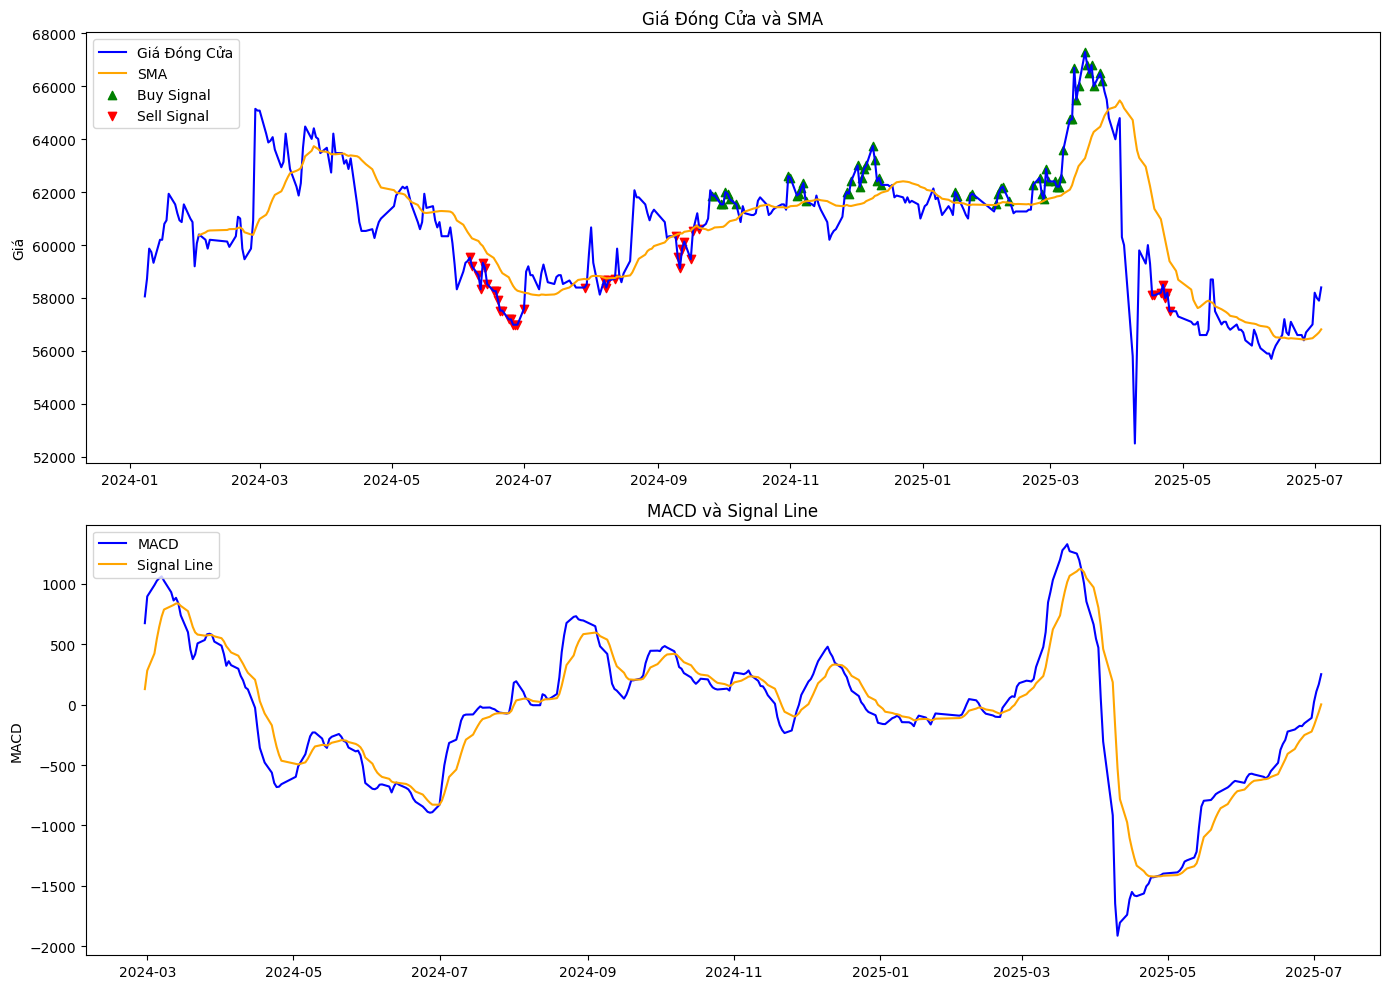

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import talib

# Giả sử DataFrame 'data' đã được tạo và chứa cột 'Datetime' và 'Close'
# Thiết lập 'Datetime' làm chỉ mục của DataFrame
# Kiem tra Datetime co phai la column hay khong, thi moi set index
if 'Datetime' in data.columns:
	data.set_index('Datetime', inplace=True)

# Thiết lập cửa sổ thời gian cho SMA và độ lệch chuẩn
window = 20  # Số ngày để tính toán SMA
# Tính toán SMA cho giá đóng cửa
data['SMA'] = talib.SMA(data['Close'], timeperiod=window)

# Tinh tay
# Tính toán độ lệch chuẩn cho giá đóng cửa
# Tính toán MACD
# EMA ngắn hạn
# data['short_ema'] = data['Close'].ewm(span=12, adjust=False).mean()
# # EMA dài hạn
# data['long_ema']  = data['Close'].ewm(span=26, adjust=False).mean()
# # Tính MACD
# data['MACD'] = data['short_ema']  - data['long_ema']
# # Tính Signal Line
# data['Signal_Line'] = data['MACD'].ewm(span=9, adjust=False).mean()
# data['EMA50'] = data['Close'].ewm(span=50, adjust=False).mean()
# data['EMA100'] = data['Close'].ewm(span=100, adjust=False).mean()

# Tính toán MACD và Signal Line
data['MACD'], data['Signal_Line'], _  = talib.MACD(data['Close'], fastperiod=12, slowperiod=26, signalperiod=9)
# Tính toán EMA 50 và EMA 100	
data['EMA50'] = talib.EMA(data['Close'], timeperiod=50) # Neu khong dung talib => Tinh toan bang cong thuc
data['EMA100'] = talib.EMA(data['Close'], timeperiod=100)

# Tạo cột tín hiệu mua/bán
# Tín hiệu mua: MACD cắt lên Signal Line và giá đóng cửa lớn hơn SMA va EMA50 lớn hơn EMA100
# Tín hiệu bán: MACD cắt xuống Signal Line và giá đóng cửa nhỏ hơn SMA va EMA50 nhỏ hơn EMA100
data['Buy_Signal'] = (data['MACD'] > data['Signal_Line']) & (data['Close'] > data['SMA']) & (data['EMA50'] > data['EMA100'])
data['Sell_Signal'] = (data['MACD'] < data['Signal_Line']) & (data['Close'] < data['SMA']) & (data['EMA50'] < data['EMA100'])

# Vẽ biểu đồ
plt.figure(figsize=(14, 10))

# Biểu đồ giá đóng cửa và SMA
plt.subplot(211)  # 2 hàng, 1 cột, biểu đồ thứ 1
plt.plot(data.index, data['Close'], label='Giá Đóng Cửa', color='blue')
plt.plot(data.index, data['SMA'], label='SMA', color='orange')

# Lọc và vẽ các điểm cho tín hiệu mua
buy_signals = data[data['Buy_Signal']]
plt.scatter(buy_signals.index, buy_signals['Close'], label='Buy Signal', marker='^', color='green')
# Lọc và vẽ các điểm cho tín hiệu bán
sell_signals = data[data['Sell_Signal']]
plt.scatter(sell_signals.index, sell_signals['Close'], label='Sell Signal', marker='v', color='red')

plt.legend(loc='upper left')
plt.title('Giá Đóng Cửa và SMA')
plt.ylabel('Giá')

# Biểu đồ MACD
plt.subplot(212)  # 2 hàng, 1 cột, biểu đồ thứ 2
plt.plot(data.index, data['MACD'], label='MACD', color='blue')
plt.plot(data.index, data['Signal_Line'], label='Signal Line', color='orange')
plt.legend(loc='upper left')
plt.title('MACD và Signal Line')
plt.ylabel('MACD')

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import plotly.graph_objects as go

# ... (Giữ phần import và tính toán MACD/SMA giống như bạn đã làm)

####################################################################################################
# Tạo figure
fig = go.Figure()

# Biểu đồ giá đóng cửa và SMA
fig.add_trace(go.Scatter(x=data.index, y=data['Close'], mode='lines', name='Giá Đóng Cửa', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=data.index, y=data['SMA'], mode='lines', name='SMA', line=dict(color='orange')))

# Vẽ các điểm cho tín hiệu mua
buy_signals = data[data['Buy_Signal']]
fig.add_trace(go.Scatter(x=buy_signals.index, y=buy_signals['Close'], mode='markers', name='Buy Signal', marker=dict(symbol='triangle-up', size=10, color='green')))

# Vẽ các điểm cho tín hiệu bán
sell_signals = data[data['Sell_Signal']]
fig.add_trace(go.Scatter(x=sell_signals.index, y=sell_signals['Close'], mode='markers', name='Sell Signal', marker=dict(symbol='triangle-down', size=10, color='red')))

fig.update_layout(title='Giá Đóng Cửa và SMA', yaxis_title='Giá', xaxis_rangeslider_visible=False, height=500)

# Hiển thị biểu đồ
fig.show()

####################################################################################################

# Tạo figure
fig = go.Figure()

# Biểu đồ MACD và Signal Line
fig.add_trace(go.Scatter(x=data.index, y=data['MACD'], mode='lines', name='MACD', line=dict(color='blue')))
fig.add_trace(go.Scatter(x=data.index, y=data['Signal_Line'], mode='lines', name='Signal Line', line=dict(color='orange')))

fig.update_layout(title='MACD và Signal Line', yaxis_title='MACD', xaxis_rangeslider_visible=False, height=500)

# Hiển thị biểu đồ
fig.show()


In [20]:
data

,Symbol,Open,High,Low,Close,Volume,SMA,MACD,Signal_Line,EMA50,EMA100,Buy_Signal,Sell_Signal
Datetime,,,,,,,,,,,,,
2024-01-08,VCB,57726,58061,57726,58061,1607800,NaN,NaN,NaN,NaN,NaN,False,False
2024-01-09,VCB,58061,58796,58061,58729,1926400,NaN,NaN,NaN,NaN,NaN,False,False
2024-01-10,VCB,58729,59867,58328,59867,1795400,NaN,NaN,NaN,NaN,NaN,False,False
2024-01-11,VCB,59867,60201,59265,59733,1489100,NaN,NaN,NaN,NaN,NaN,False,False
2024-01-12,VCB,58930,59867,58462,59331,1909500,NaN,NaN,NaN,NaN,NaN,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-30,VCB,57000,57200,56900,57000,2952200,56480.0,-109.314577,-222.771623,57479.893104,58780.148132,False,False
2025-07-01,VCB,57200,58800,57100,58200,10049500,56550.0,22.472557,-173.722787,57508.132590,58768.660050,False,False
2025-07-02,VCB,58300,58600,57700,58000,2913600,56620.0,109.514071,-117.075415,57527.421508,58753.439059,False,False


In [21]:
data.to_csv('data 2025.07.04.csv')

In [ ]:
data

# Quy ước code


.1 là chiến lược
.2 là đẩy qua redis
.3 là xây dựng OG (Order Good)
.4 là xây dựng OF (Order Follower)
.5 là backtest
.6 là xây dựng OM (Order Monitoring)
.7 là xây dựng OR (Order Risk quản lý rủi ro)

# Backtest Co Phieu

In [25]:
data['Open'] = pd.to_numeric(data['Open'], errors='coerce')
data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 369 entries, 2024-01-08 to 2025-07-04
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Symbol         369 non-null    object 
 1   Open           369 non-null    int64  
 2   High           369 non-null    object 
 3   Low            369 non-null    object 
 4   Close          369 non-null    int64  
 5   Volume         369 non-null    object 
 6   SMA            350 non-null    float64
 7   MACD           336 non-null    float64
 8   Signal_Line    336 non-null    float64
 9   EMA50          320 non-null    float64
 10  EMA100         270 non-null    float64
 11  Buy_Signal     369 non-null    bool   
 12  Sell_Signal    369 non-null    bool   
 13  Position_Buy   368 non-null    object 
 14  Position_Sell  368 non-null    object 
 15  Trade_Action   369 non-null    object 
 16  Capital        369 non-null    int64  
 17  Shares_Held    369 non-null    int6

Ngày vào lệnh đầu tiên: 2024-09-27 00:00:00
Tổng lợi nhuận: -5411500
Tổng giá trị tài khoản: 94588500
Lợi nhuận thị trường: 0.5838686898262172%
Lợi nhuận chiến lược: -5.4115%


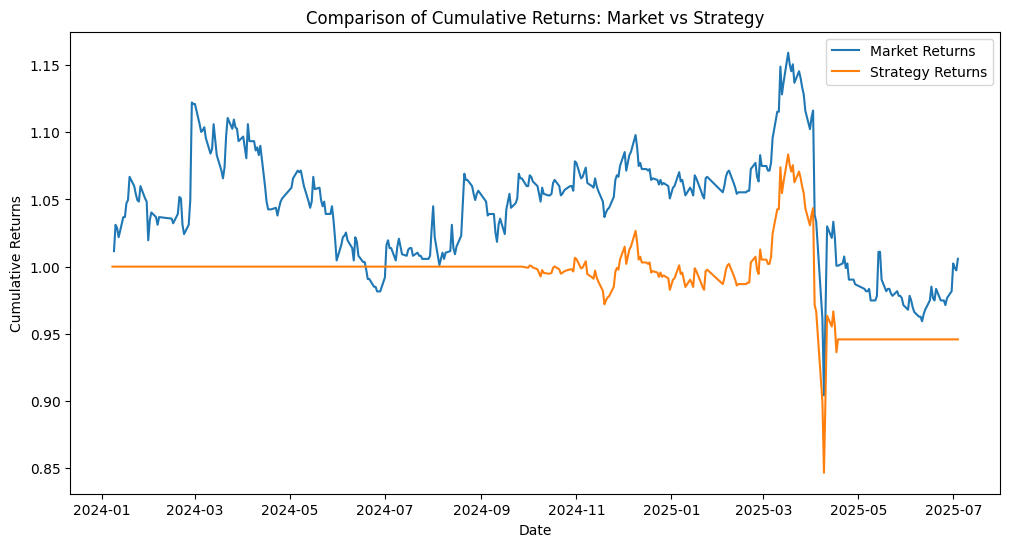

,Symbol,Open,High,Low,Close,Volume,SMA,MACD,Signal_Line,EMA50,...,Sell_Signal,Position_Buy,Position_Sell,Trade_Action,Capital,Shares_Held,Market_Return,Cumulative_Market_Returns,Strategy_Value,Cumulative_Strategy_Returns
Datetime,,,,,,,,,,,,,,,,,,,,,
2024-01-08,VCB,57726,58061,57726,58061,1607800,NaN,NaN,NaN,NaN,...,False,NaN,NaN,,100000000,0,NaN,NaN,100000000,1.000000
2024-01-09,VCB,58061,58796,58061,58729,1926400,NaN,NaN,NaN,NaN,...,False,False,False,,100000000,0,0.011505,1.011505,100000000,1.000000
2024-01-10,VCB,58729,59867,58328,59867,1795400,NaN,NaN,NaN,NaN,...,False,False,False,,100000000,0,0.019377,1.031105,100000000,1.000000
2024-01-11,VCB,59867,60201,59265,59733,1489100,NaN,NaN,NaN,NaN,...,False,False,False,,100000000,0,-0.002238,1.028797,100000000,1.000000
2024-01-12,VCB,58930,59867,58462,59331,1909500,NaN,NaN,NaN,NaN,...,False,False,False,,100000000,0,-0.006730,1.021874,100000000,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-06-30,VCB,57000,57200,56900,57000,2952200,56480.0,-109.314577,-222.771623,57479.893104,...,False,False,False,,94588500,0,0.005291,0.981726,94588500,0.945885
2025-07-01,VCB,57200,58800,57100,58200,10049500,56550.0,22.472557,-173.722787,57508.132590,...,False,False,False,,94588500,0,0.021053,1.002394,94588500,0.945885
2025-07-02,VCB,58300,58600,57700,58000,2913600,56620.0,109.514071,-117.075415,57527.421508,...,False,False,False,,94588500,0,-0.003436,0.998949,94588500,0.945885


In [27]:
import sys
sys.path.append("../Common")
# from CommonBacktest import CommonBacktest
import CommonBacktest


# data: DataFrame chứa dữ liệu giá cổ phiếu với các cột 'Buy_Signal' và 'Sell_Signal'
# initial_capital: Số tiền ban đầu để đầu tư
# shares_per_signal: Số lượng cổ phiếu mua/bán mỗi khi có tín hiệu

# Data la data co phai co Buy_Signal, Sell_Signal
backtest = CommonBacktest.CommonBacktest.backtest(data, 100000000, 100)

backtest.to_csv('data_out_backtest.csv')
backtest